In [ ]:
!git clone https://gitlab.developers.cam.ac.uk/ch/thom/part2programming.git

Cloning into 'part2programming'...
remote: Enumerating objects: 4555, done.
remote: Total 4555 (delta 0), reused 0 (delta 0), pack-reused 4555 (from 1)
Receiving objects: 100% (4555/4555), 5.05 MiB | 4.09 MiB/s, done.
Resolving deltas: 100% (4527/4527), done.


Enter the molecule in capital letters (H2O or H2S): H2O
Total files to read: 2160


/tmp/ipykernel_255/1924289688.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_table = pd.concat([data_table, parse_output_file(file_text)], ignore_index=True)


         r  theta     Energy
0     0.70   70.0 -75.707054
1     0.70   71.0 -75.710981
2     0.70   72.0 -75.714767
3     0.70   73.0 -75.718415
4     0.70   74.0 -75.721930
...    ...    ...        ...
2155  1.85  155.0 -75.578780
2156  1.85  156.0 -75.577681
2157  1.85  157.0 -75.576585
2158  1.85  158.0 -75.575494
2159  1.85  159.0 -75.574410

[2160 rows x 3 columns]

Equilibrium geometry:
r           0.950000
theta     105.000000
Energy    -76.024288
Name: 485, dtype: float64


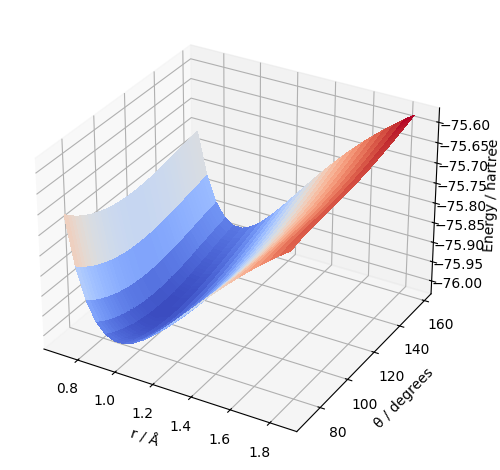


Stretching frequency (cm^-1): 3982.4395674805105
Bending frequency (cm^-1): 1714.224385023228


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Point
import re
import pandas as pd
from urllib.request import urlopen
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

molecule_label = input("Enter the molecule in capital letters (H2O or H2S): ").strip().upper()

# build list of URLs for all geometries
url_list = []

# Each molecule's data range is different so we separate into 2 cases
if molecule_label == "H2O":
    # H2O: bond lengths from 0.70 Å in steps of 0.05 Å, angles 70–159°
    for r_index in range(24):
        for theta_index in range(90):
            bond_length = format(0.70 + r_index * 0.05, ".2f")
            bond_angle = 70 + theta_index
            url = (
                "https://gitlab.developers.cam.ac.uk/ch/thom/part2programming/"
                f"-/raw/master/Ex2/{molecule_label}outfiles/"
                f"{molecule_label}.r{bond_length}theta{bond_angle}.0.out"
            )
            url_list.append(url)

elif molecule_label == "H2S":
    # H2S: bond lengths from 0.60 Å in steps of 0.05 Å, angles 70–159°
    for r_index in range(24):
        for theta_index in range(90):
            bond_length = format(0.60 + r_index * 0.05, ".2f")
            bond_angle = 70 + theta_index
            url = (
                "https://gitlab.developers.cam.ac.uk/ch/thom/part2programming/"
                f"-/raw/master/Ex2/{molecule_label}outfiles/"
                f"{molecule_label}.r{bond_length}theta{bond_angle}.0.out"
            )
            url_list.append(url)
else:
    raise ValueError("Only H2O or H2S")

print(f"Total files to read: {len(url_list)}")

# extract geometry and energy from one output file
def parse_output_file(file_text):
    bond_length = None
    bond_angle = None
    energy_value = None
#   bond length (r) from the filename pattern inside the file
    geom_pattern = r"r(\d+\.\d+)theta(\d+\.\d+)"
#   - the RHF energy from the line starting with "E(RHF) ="
    energy_pattern = r"E\(RHF\)\s*=\s*(-?\d+\.\d+)"

    geom_match = re.search(geom_pattern, file_text)
    energy_match = re.search(energy_pattern, file_text)

    if geom_match and energy_match:
        bond_length = float(geom_match.group(1))
        bond_angle = float(geom_match.group(2))
        energy_value = float(energy_match.group(1))

    row = pd.DataFrame(
        {"r": [bond_length], "theta": [bond_angle], "Energy": [energy_value]}
    )
    return row


# read all files and build main data table
data_table = pd.DataFrame(columns=["r", "theta", "Energy"])

for url in url_list:
    with urlopen(url) as response:
        file_text = response.read().decode("utf-8")
        data_table = pd.concat([data_table, parse_output_file(file_text)], ignore_index=True)

print(data_table)

# locate equilibrium geometry with lowest energy
eq_row = data_table.loc[data_table["Energy"].idxmin()]
theta_eq = eq_row["theta"]
r_eq = eq_row["r"]
energy_eq = eq_row["Energy"]

print("\nEquilibrium geometry:")
print(eq_row)

# make 3D plot: sort data for surface plotting so each combination of r & theta appears only once
data_table = data_table.sort_values(by=["theta", "r"])

r_values = data_table["r"].values
theta_values = data_table["theta"].values
energy_values = data_table["Energy"].values

# make a regular grid in r and theta with increments based on those in section 1
r_grid, theta_grid = np.meshgrid(
    np.linspace(r_values.min(), r_values.max(), int(round((r_values.max() - r_values.min()) / 0.05 + 1))),
    np.linspace(theta_values.min(), theta_values.max(), int(round(theta_values.max() - theta_values.min() + 1))),
)

# reshape energy values to match the grid, grid dimensions correspond to the (r, theta) combinations
energy_grid = energy_values.reshape(theta_grid.shape)

# 3D surface plot of potential energy surface
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    r_grid,
    theta_grid,
    energy_grid,
    cmap=cm.coolwarm,
    linewidth=0,
    antialiased=False,
)

ax.set_xlabel("r / Å")
ax.set_ylabel("θ / degrees")
ax.set_zlabel("Energy / hartree")

plt.tight_layout()
plt.show()

# STRETCH MODE

# r points close to equilibrium bond length
r_offset = np.arange(-0.2, 0.3, 0.05)
r_sample = [round(r_eq + dr, 2) for dr in r_offset]
# extract the subset of data at the equilibrium theta and the selected r values
stretch_slice = data_table[
    (data_table["theta"] == theta_eq) & (data_table["r"].isin(r_sample))
].sort_values(by="r")
# convert displacement in A to meters, and energy from hartree to joules.
r_offset_bohr = np.array(stretch_slice["r"].values - r_eq) * 1e-10  # displacement in m
energy_stretch = stretch_slice["Energy"].values * 4.35974e-18       # hartree to J

# fit harmonic potential to energy as a function of displacement E = a x^2 + b x + c
coeff_stretch = np.polyfit(r_offset_bohr, energy_stretch, 2)
k_r = 2 * coeff_stretch[0]  # force constant along r since E ~ 1/2 kx^2

# reduced mass for AH2 bending/stretching (approx. 2*atomic mass unit)
reduced_mass = 2 * 1.66053886e-27
# frequency in hz and then convert to cm
freq1_hz = np.sqrt(k_r / reduced_mass) / (2 * np.pi)
freq1_cm = freq1_hz * 3.3356e-11

print("\nStretching frequency (cm^-1):", freq1_cm)

# BENDING MODE

# choose angles near equilibrium
theta_offset = np.arange(-15, 15, 1)
theta_sample = theta_eq + theta_offset
# extract the subset of data at fixed r and the selected theta values
bend_slice = data_table[
    (data_table["r"] == r_eq) & (data_table["theta"].isin(theta_sample))
].sort_values(by="theta")
# convert angular displacement from degrees to radians
theta_rad = (bend_slice["theta"].values - theta_eq) * 2 * np.pi / 360.0
energy_bend = bend_slice["Energy"].values * 4.35974e-18
# fit a quadratic to energy vs angular displacement
coeff_bend = np.polyfit(theta_rad, energy_bend, 2)
k_theta = 2 * coeff_bend[0]

bend_factor = r_eq * 1e-10 * r_eq * 0.5e-10 * 1.66053886e-27

freq2_hz = np.sqrt(k_theta / bend_factor) / (2 * np.pi)
freq2_cm = freq2_hz * 3.3356e-11

print("Bending frequency (cm^-1):", freq2_cm)